# BKK 3-Class V4 Strong-First Recall-Constrained Models

This notebook changes the hierarchy so the rare, operationally important class is evaluated first:

1. Stage 1 predicts `moderate_or_heavy` (`>= 2.5 mm`) versus all other rows.
2. Stage 2 classifies rows not selected as strong rain into `light` versus `no_rain`.
3. Validation threshold tuning enforces a hard strong-rain recall target, then maximizes precision and macro F1.

Final classes:

- `0 = no_rain`: `< 0.1 mm`
- `1 = light`: `0.1 mm` to `< 2.5 mm`
- `2 = moderate_or_heavy`: `>= 2.5 mm`

The 82% validation recall target provides a buffer for the 8-14 percentage-point validation-to-test recall decline observed in V3.


## 1. Setup


In [1]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


## 2. Configuration


In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"OM_BKK_DATA"'
PRECOMPUTE_TABLE_NAME = '"OM_BKK_DATA_PRECOMPUTE"'
PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "BKK_3_Class_V4"

HORIZONS = [1, 2, 3, 4, 5, 6]
CLASS_LABELS = {
    0: "no_rain",
    1: "light",
    2: "moderate_or_heavy",
}
CLASS_ORDER = list(CLASS_LABELS)
INTENSITY_THRESHOLDS_MM = {
    "rain_min": 0.1,
    "moderate_or_heavy_min": 2.5,
}

STRONG_PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.01, 0.62, 0.02)
LIGHT_PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.20, 0.81, 0.05)
TARGET_VALIDATION_STRONG_RECALL = 0.82
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_ROWS = None
RANDOM_STATE = 42


## 3. Feature Columns


In [3]:
BASELINE_FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m", "pressure_msl", "surface_pressure",
    "dew_point_2m", "precipitation", "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "temperature_dew_point_spread", "pressure_msl_change_3h",
    "pressure_msl_change_6h", "precipitation_lag_1h", "precipitation_lag_2h",
    "precipitation_lag_3h", "precipitation_lag_6h", "precipitation_sum_past_3h",
    "precipitation_sum_past_6h", "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "cloud_cover_lag_1h", "cloud_cover_lag_3h", "cloud_cover_lag_6h",
    "humidity_lag_1h", "humidity_lag_3h", "humidity_lag_6h",
    "wind_speed_lag_1h", "wind_speed_lag_3h", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "grid_row", "grid_column", "latitude", "longitude",
]

NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count", "neighbor_precipitation_mean", "neighbor_precipitation_max",
    "neighbor_precipitation_sum", "neighbor_rain_count", "neighbor_rain_rate",
    "neighbor_cloud_cover_mean", "neighbor_cloud_cover_max", "neighbor_relative_humidity_mean",
    "neighbor_relative_humidity_max", "neighbor_pressure_msl_mean", "neighbor_pressure_msl_min",
    "neighbor_pressure_msl_max", "neighbor_temperature_2m_mean", "neighbor_dew_point_2m_mean",
    "neighbor_temperature_dew_point_spread_mean", "neighbor_wind_speed_10m_mean",
    "neighbor_wind_speed_10m_max", "row_minus_precipitation_mean", "row_plus_precipitation_mean",
    "column_minus_precipitation_mean", "column_plus_precipitation_mean", "row_minus_cloud_cover_mean",
    "row_plus_cloud_cover_mean", "column_minus_cloud_cover_mean", "column_plus_cloud_cover_mean",
    "neighbor_precipitation_mean_minus_center", "neighbor_cloud_cover_mean_minus_center",
    "neighbor_relative_humidity_mean_minus_center", "center_pressure_msl_minus_neighbor_mean",
]

FEATURE_COLUMNS = BASELINE_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS
FUTURE_PRECIP_COLUMNS = [f"precipitation_next_{horizon}h" for horizon in HORIZONS]
FINAL_TARGET_COLUMNS = [f"rain_3class_next_{horizon}h" for horizon in HORIZONS]
STRONG_TARGET_COLUMNS = [f"strong_vs_rest_next_{horizon}h" for horizon in HORIZONS]
LIGHT_TARGET_COLUMNS = [f"light_vs_no_rain_next_{horizon}h" for horizon in HORIZONS]
TARGET_COLUMNS = FINAL_TARGET_COLUMNS + STRONG_TARGET_COLUMNS + LIGHT_TARGET_COLUMNS

print(f"Features used: {len(FEATURE_COLUMNS)}")
print(f"Final 3-class targets: {FINAL_TARGET_COLUMNS}")
print(f"Class labels: {CLASS_LABELS}")


Features used: 66
Final 3-class targets: ['rain_3class_next_1h', 'rain_3class_next_2h', 'rain_3class_next_3h', 'rain_3class_next_4h', 'rain_3class_next_5h', 'rain_3class_next_6h']
Class labels: {0: 'no_rain', 1: 'light', 2: 'moderate_or_heavy'}


## 4. Load Precomputed Features And Build Targets


In [4]:
def connect():
    return psycopg2.connect(**DB_CONFIG)


def rain_3class(precipitation_mm):
    bins = [
        -np.inf,
        INTENSITY_THRESHOLDS_MM["rain_min"],
        INTENSITY_THRESHOLDS_MM["moderate_or_heavy_min"],
        np.inf,
    ]
    return pd.cut(
        precipitation_mm,
        bins=bins,
        labels=CLASS_ORDER,
        right=False,
    ).astype("int8")


def read_training_data(sample_rows=None):
    select_columns = [
        "grid_number",
        "local_forecast_time AS forecast_time",
        *FEATURE_COLUMNS,
        *FUTURE_PRECIP_COLUMNS,
    ]
    select_sql = ",\n        ".join(select_columns)
    query = f'''
    SELECT
        {select_sql}
    FROM {PRECOMPUTE_TABLE_NAME}
    WHERE pressure_msl_change_6h IS NOT NULL
      AND precipitation_lag_6h IS NOT NULL
      AND precipitation_sum_past_24h IS NOT NULL
      AND cloud_cover_lag_6h IS NOT NULL
      AND humidity_lag_6h IS NOT NULL
      AND wind_speed_lag_3h IS NOT NULL
      AND precipitation_next_{max(HORIZONS)}h IS NOT NULL
      AND neighbor_count > 0
    ORDER BY local_forecast_time, grid_number
    '''
    if sample_rows:
        query = f'''
        SELECT *
        FROM ({query}) complete_rows
        ORDER BY random()
        LIMIT {int(sample_rows)}
        '''
    with connect() as conn:
        data = pd.read_sql_query(query, conn, parse_dates=["forecast_time"])

    for horizon in HORIZONS:
        final_target = f"rain_3class_next_{horizon}h"
        strong_target = f"strong_vs_rest_next_{horizon}h"
        light_target = f"light_vs_no_rain_next_{horizon}h"
        data[final_target] = rain_3class(data[f"precipitation_next_{horizon}h"])
        data[strong_target] = (data[final_target] == 2).astype("int8")
        data[light_target] = (data[final_target] == 1).astype("int8")
    return data


In [5]:
df = read_training_data(SAMPLE_ROWS)
print(df.shape)
print(df["forecast_time"].min(), "to", df["forecast_time"].max())
display(df.head())

required_columns = sorted(set(FEATURE_COLUMNS + FUTURE_PRECIP_COLUMNS + TARGET_COLUMNS))
missing_counts = df[required_columns].isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0])


C:\Users\Brandon\AppData\Local\Temp\ipykernel_23868\3852645400.py:50: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql_query(query, conn, parse_dates=["forecast_time"])


(2453472, 92)
2021-07-20 06:00:00 to 2026-07-19 17:00:00


,grid_number,forecast_time,temperature_2m,relative_humidity_2m,pressure_msl,surface_pressure,dew_point_2m,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m,temperature_dew_point_spread,pressure_msl_change_3h,pressure_msl_change_6h,precipitation_lag_1h,precipitation_lag_2h,precipitation_lag_3h,precipitation_lag_6h,precipitation_sum_past_3h,precipitation_sum_past_6h,precipitation_sum_past_12h,precipitation_sum_past_24h,cloud_cover_lag_1h,cloud_cover_lag_3h,cloud_cover_lag_6h,humidity_lag_1h,humidity_lag_3h,humidity_lag_6h,wind_speed_lag_1h,wind_speed_lag_3h,hour_sin,hour_cos,month_sin,month_cos,grid_row,grid_column,latitude,longitude,neighbor_count,neighbor_precipitation_mean,neighbor_precipitation_max,neighbor_precipitation_sum,neighbor_rain_count,neighbor_rain_rate,neighbor_cloud_cover_mean,neighbor_cloud_cover_max,neighbor_relative_humidity_mean,neighbor_relative_humidity_max,neighbor_pressure_msl_mean,neighbor_pressure_msl_min,neighbor_pressure_msl_max,neighbor_temperature_2m_mean,neighbor_dew_point_2m_mean,neighbor_temperature_dew_point_spread_mean,neighbor_wind_speed_10m_mean,neighbor_wind_speed_10m_max,row_minus_precipitation_mean,row_plus_precipitation_mean,column_minus_precipitation_mean,column_plus_precipitation_mean,row_minus_cloud_cover_mean,row_plus_cloud_cover_mean,column_minus_cloud_cover_mean,column_plus_cloud_cover_mean,neighbor_precipitation_mean_minus_center,neighbor_cloud_cover_mean_minus_center,neighbor_relative_humidity_mean_minus_center,center_pressure_msl_minus_neighbor_mean,precipitation_next_1h,precipitation_next_2h,precipitation_next_3h,precipitation_next_4h,precipitation_next_5h,precipitation_next_6h,rain_3class_next_1h,strong_vs_rest_next_1h,light_vs_no_rain_next_1h,rain_3class_next_2h,strong_vs_rest_next_2h,light_vs_no_rain_next_2h,rain_3class_next_3h,strong_vs_rest_next_3h,light_vs_no_rain_next_3h,rain_3class_next_4h,strong_vs_rest_next_4h,light_vs_no_rain_next_4h,rain_3class_next_5h,strong_vs_rest_next_5h,light_vs_no_rain_next_5h,rain_3class_next_6h,strong_vs_rest_next_6h,light_vs_no_rain_next_6h
0,1,2021-07-20 06:00:00,26.4000,87.0000,1005.6000,1005.4000,24.0000,2.4000,100.0000,18.0000,217.0000,2.4000,-0.3000,-1.8000,1.7000,1.0000,0.6000,0.3000,5.1000,6.2000,6.5000,6.5000,99.0000,99.0000,99.0000,87.0000,87.0000,87.0000,19.7000,19.9000,1.0000,0.0000,-0.5000,-0.8660,1,1,13.4940,100.3270,3.0000,2.2667,2.5000,6.8000,3.0000,1.0000,100.0000,100.0000,88.0000,90.0000,1005.6333,1005.6000,1005.7000,26.1667,23.9333,2.2333,15.8667,19.2000,0.0000,2.4000,0.0000,2.1500,100.0000,100.0000,100.0000,100.0000,-0.1333,0.0000,1.0000,-0.0333,1.2000,0.7000,0.2000,0.0000,0.1000,0.1000,1,0,1,1,0,1,1,0,1,0,0,0,1,0,1,1,0,1
1,2,2021-07-20 06:00:00,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,-1.7000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,3.9000,99.0000,100.0000,100.0000,82.0000,82.0000,82.0000,23.2000,23.2000,1.0000,0.0000,-0.5000,-0.8660,1,2,13.4940,100.4102,5.0000,2.2800,2.5000,11.4000,5.0000,1.0000,100.0000,100.0000,87.8000,90.0000,1005.6400,1005.6000,1005.7000,26.2200,23.9800,2.2400,16.4400,19.2000,0.0000,2.3333,2.4500,2.1000,100.0000,100.0000,100.0000,100.0000,0.2800,0.0000,2.8000,0.0600,1.1000,0.7000,0.1000,0.0000,0.0000,0.0000,1,0,1,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0
2,3,2021-07-20 06:00:00,26.7000,85.0000,1005.7000,1005.7000,23.9000,2.0000,100.0000,19.2000,218.0000,2.8000,-0.3000,-1.7000,1.0000,0.4000,0.0000,0.3000,3.4000,3.6000,3.9000,3.9000,99.0000,100.0000,100.0000,82.0000,82.0000,82.0000,23.2000,23.2000,1.0000,0.0000,-0.5000,-0.8660,1,3,13.4940,100.4934,5.0000,1.9400,2.3000,9.7000,5.0000,1.0000,100.0000,100.0000,86.8000,89.0000,1005.7000,1005.6000,1005.8000,26.4000,23.9800,2.4200,17.2600,19.2000,0.0000,2.1000,2.1500,1.6000,100.0000,100.0000,100.0000,100.0000,-0.0600,0.0000,1.8000,0.0000,1.1000,0.7000,0.1000,0.0000,0.0000,0.0000,1,0,1,1,0,1,1,0,1,0,0,0,0,0,0,0,0,0
3,4,2021-07-20 06:00:00,26.6000,86.0000,1005.8000,1005.8000,24.0000,1.4000,100.0000,18.300

Series([], dtype: int64)

## 5. Class Balance


,horizon_h,target_column,class_id,class_label,rows,class_rate
0,1,rain_3class_next_1h,0,no_rain,1912354,0.7794
1,1,rain_3class_next_1h,1,light,486696,0.1984
2,1,rain_3class_next_1h,2,moderate_or_heavy,54422,0.0222
3,2,rain_3class_next_2h,0,no_rain,1912410,0.7795
4,2,rain_3class_next_2h,1,light,486642,0.1983
5,2,rain_3class_next_2h,2,moderate_or_heavy,54420,0.0222
6,3,rain_3class_next_3h,0,no_rain,1912459,0.7795
7,3,rain_3class_next_3h,1,light,486593,0.1983
8,3,rain_3class_next_3h,2,moderate_or_heavy,54420,0.0222
9,4,rain_3class_next_4h,0,no_rain,1912492,0.7795


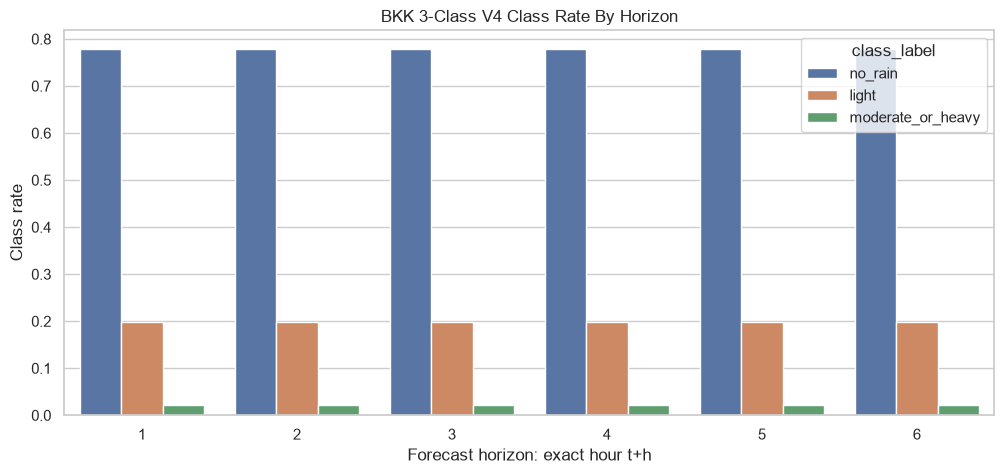

In [6]:
balance_rows = []
for horizon in HORIZONS:
    target = f"rain_3class_next_{horizon}h"
    counts = df[target].value_counts().reindex(CLASS_ORDER, fill_value=0)
    for class_id, rows in counts.items():
        balance_rows.append({
            "horizon_h": horizon,
            "target_column": target,
            "class_id": int(class_id),
            "class_label": CLASS_LABELS[int(class_id)],
            "rows": int(rows),
            "class_rate": float(rows / len(df)),
        })

target_balance = pd.DataFrame(balance_rows)
display(target_balance)

sns.barplot(data=target_balance, x="horizon_h", y="class_rate", hue="class_label")
plt.title("BKK 3-Class V4 Class Rate By Horizon")
plt.xlabel("Forecast horizon: exact hour t+h")
plt.ylabel("Class rate")
plt.show()


## 6. Chronological Split


In [7]:
def add_time_split(data, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.array(sorted(data["forecast_time"].unique()))
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]
    out = data.copy()
    out["split"] = "test"
    out.loc[out["forecast_time"] < train_end, "split"] = "train"
    out.loc[(out["forecast_time"] >= train_end) & (out["forecast_time"] < validation_end), "split"] = "validation"
    return out, train_end, validation_end

model_df, train_end, validation_end = add_time_split(df, TRAIN_FRACTION, VALIDATION_FRACTION)
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")
display(model_df.groupby("split").size().rename("rows").reset_index())

train_df = model_df[model_df["split"] == "train"]
validation_df = model_df[model_df["split"] == "validation"]
test_df = model_df[model_df["split"] == "test"]

x_train = train_df[FEATURE_COLUMNS].astype("float32")
x_validation = validation_df[FEATURE_COLUMNS].astype("float32")
x_test = test_df[FEATURE_COLUMNS].astype("float32")


Train before: 2025-01-18 02:00:00
Validation before: 2025-10-18 22:00:00


,split,rows
0,test,368032
1,train,1717408
2,validation,368032


## 7. Strong-First Evaluation And Constrained Threshold Tuning

In [8]:
def predict_three_class(strong_probability, light_probability, strong_threshold, light_threshold):
    predictions = np.zeros(len(strong_probability), dtype="int8")
    strong_mask = strong_probability >= strong_threshold
    predictions[strong_mask] = 2
    predictions[(~strong_mask) & (light_probability >= light_threshold)] = 1
    return predictions


def class_metric_rows(y_true, y_pred, strong_probability, light_probability, model_name, horizon, split, strong_threshold, light_threshold):
    rows = []
    for class_id, class_label in CLASS_LABELS.items():
        binary_true = (y_true == class_id).astype("int8")
        binary_pred = (y_pred == class_id).astype("int8")
        rows.append({
            "model": model_name,
            "target_type": "exact_hour_3class_strong_first_recall_constrained",
            "feature_set": "neighbor_grid",
            "horizon_h": horizon,
            "split": split,
            "class_id": class_id,
            "class_label": class_label,
            "rows": int(len(y_true)),
            "class_rate": float(binary_true.mean()),
            "predicted_class_rate": float(binary_pred.mean()),
            "precision": float(precision_score(binary_true, binary_pred, zero_division=0)),
            "recall": float(recall_score(binary_true, binary_pred, zero_division=0)),
            "f1": float(f1_score(binary_true, binary_pred, zero_division=0)),
            "strong_threshold": float(strong_threshold),
            "light_threshold": float(light_threshold),
            "mean_strong_probability": float(strong_probability.mean()),
            "mean_light_probability": float(light_probability.mean()),
        })
    return rows


def evaluate_predictions(y_true, y_pred, strong_probability, light_probability, model_name, horizon, split, strong_threshold, light_threshold):
    strong_true = (y_true == 2).astype("int8")
    rain_true = (y_true > 0).astype("int8")
    rain_pred = (y_pred > 0).astype("int8")
    base = {
        "model": model_name,
        "target_type": "exact_hour_3class_strong_first_recall_constrained",
        "feature_set": "neighbor_grid",
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, labels=CLASS_ORDER, average="weighted", zero_division=0)),
        "rain_precision": float(precision_score(rain_true, rain_pred, zero_division=0)),
        "rain_recall": float(recall_score(rain_true, rain_pred, zero_division=0)),
        "strong_average_precision": float(average_precision_score(strong_true, strong_probability)),
        "strong_threshold": float(strong_threshold),
        "light_threshold": float(light_threshold),
    }
    class_rows = class_metric_rows(
        y_true, y_pred, strong_probability, light_probability, model_name, horizon, split, strong_threshold, light_threshold
    )
    confusion = pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=CLASS_ORDER),
        index=[f"actual_{CLASS_LABELS[i]}" for i in CLASS_ORDER],
        columns=[f"predicted_{CLASS_LABELS[i]}" for i in CLASS_ORDER],
    ).reset_index(names="actual_class")
    confusion.insert(0, "horizon_h", horizon)
    confusion.insert(1, "split", split)
    confusion.insert(2, "strong_threshold", float(strong_threshold))
    confusion.insert(3, "light_threshold", float(light_threshold))
    return base, class_rows, confusion


def tune_thresholds(y_true, strong_probability, light_probability):
    rows = []
    best = None
    for strong_threshold in STRONG_PROBABILITY_THRESHOLDS_TO_TEST:
        for light_threshold in LIGHT_PROBABILITY_THRESHOLDS_TO_TEST:
            y_pred = predict_three_class(strong_probability, light_probability, strong_threshold, light_threshold)
            strong_true = (y_true == 2).astype("int8")
            strong_pred = (y_pred == 2).astype("int8")
            strong_recall = recall_score(strong_true, strong_pred, zero_division=0)
            strong_precision = precision_score(strong_true, strong_pred, zero_division=0)
            candidate = {
                "strong_threshold": float(strong_threshold),
                "light_threshold": float(light_threshold),
                "meets_recall_constraint": bool(strong_recall >= TARGET_VALIDATION_STRONG_RECALL),
                "macro_f1": float(f1_score(y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0)),
                "moderate_or_heavy_precision": float(strong_precision),
                "moderate_or_heavy_recall": float(strong_recall),
                "moderate_or_heavy_f1": float(f1_score(strong_true, strong_pred, zero_division=0)),
            }
            rows.append(candidate)
            candidate_key = (
                int(candidate["meets_recall_constraint"]),
                candidate["moderate_or_heavy_precision"] if candidate["meets_recall_constraint"] else candidate["moderate_or_heavy_recall"],
                candidate["macro_f1"],
                candidate["moderate_or_heavy_recall"],
            )
            if best is None:
                best = candidate
            else:
                best_key = (
                    int(best["meets_recall_constraint"]),
                    best["moderate_or_heavy_precision"] if best["meets_recall_constraint"] else best["moderate_or_heavy_recall"],
                    best["macro_f1"],
                    best["moderate_or_heavy_recall"],
                )
                if candidate_key > best_key:
                    best = candidate
    return best.copy(), pd.DataFrame(rows)


## 8. Train Strong-First Models

In [9]:
try:
    from lightgbm import LGBMClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

strong_models = {}
light_models = {}
threshold_rows = []
threshold_search_tables = []
metric_rows = []
class_metric_rows_all = []
confusion_tables = []
feature_importance_rows = []

for horizon in HORIZONS:
    final_target = f"rain_3class_next_{horizon}h"
    strong_target = f"strong_vs_rest_next_{horizon}h"
    light_target = f"light_vs_no_rain_next_{horizon}h"
    print(f"Training V4 strong-first models for exact +{horizon}h...")

    y_final_validation = validation_df[final_target].astype("int8").to_numpy()
    y_final_test = test_df[final_target].astype("int8").to_numpy()

    strong_model = LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        n_estimators=500,
        learning_rate=0.04,
        num_leaves=63,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    strong_model.fit(
        x_train,
        train_df[strong_target].astype("int8"),
        eval_set=[(x_validation, validation_df[strong_target].astype("int8"))],
        eval_metric="binary_logloss",
    )
    strong_models[horizon] = strong_model

    nonstrong_train = train_df[final_target] != 2
    nonstrong_validation = validation_df[final_target] != 2
    light_model = LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        n_estimators=500,
        learning_rate=0.04,
        num_leaves=63,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    light_model.fit(
        train_df.loc[nonstrong_train, FEATURE_COLUMNS].astype("float32"),
        train_df.loc[nonstrong_train, light_target].astype("int8"),
        eval_set=[(
            validation_df.loc[nonstrong_validation, FEATURE_COLUMNS].astype("float32"),
            validation_df.loc[nonstrong_validation, light_target].astype("int8"),
        )],
        eval_metric="binary_logloss",
    )
    light_models[horizon] = light_model

    strong_validation_probability = strong_model.predict_proba(x_validation)[:, 1]
    light_validation_probability = light_model.predict_proba(x_validation)[:, 1]
    best_thresholds, threshold_search = tune_thresholds(
        y_final_validation, strong_validation_probability, light_validation_probability
    )
    best_thresholds["horizon_h"] = horizon
    threshold_rows.append(best_thresholds)
    threshold_search["horizon_h"] = horizon
    threshold_search_tables.append(threshold_search)

    for model_stage, model in [("strong_vs_rest", strong_model), ("light_vs_no_rain", light_model)]:
        for feature, importance in zip(FEATURE_COLUMNS, np.asarray(model.feature_importances_)):
            feature_importance_rows.append({
                "model": "lightgbm",
                "model_stage": model_stage,
                "horizon_h": horizon,
                "feature": feature,
                "importance": float(importance),
                "is_neighbor_feature": feature in NEIGHBOR_FEATURE_COLUMNS,
            })

    for split_name, x_split, y_final in [
        ("validation", x_validation, y_final_validation),
        ("test", x_test, y_final_test),
    ]:
        strong_probability = strong_model.predict_proba(x_split)[:, 1]
        light_probability = light_model.predict_proba(x_split)[:, 1]
        y_pred = predict_three_class(
            strong_probability,
            light_probability,
            best_thresholds["strong_threshold"],
            best_thresholds["light_threshold"],
        )
        metrics, class_rows, confusion = evaluate_predictions(
            y_final,
            y_pred,
            strong_probability,
            light_probability,
            "lightgbm_strong_first",
            horizon,
            split_name,
            best_thresholds["strong_threshold"],
            best_thresholds["light_threshold"],
        )
        metric_rows.append(metrics)
        class_metric_rows_all.extend(class_rows)
        confusion_tables.append(confusion)

thresholds = pd.DataFrame(threshold_rows)
threshold_search_results = pd.concat(threshold_search_tables, ignore_index=True)
all_metrics = pd.DataFrame(metric_rows)
class_metrics = pd.DataFrame(class_metric_rows_all)
confusion_results = pd.concat(confusion_tables, ignore_index=True)
feature_importance = pd.DataFrame(feature_importance_rows)

display(thresholds.sort_values("horizon_h"))
display(all_metrics.sort_values(["horizon_h", "split"]))
display(class_metrics[class_metrics["split"] == "test"].sort_values(["horizon_h", "class_id"]))
display(confusion_results[confusion_results["split"] == "test"])


Training V4 strong-first models for exact +1h...


C:\Users\Brandon\Documents\Phase 1\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Number of positive: 41673, number of negative: 1675735


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.198727 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11064
[LightGBM] [Info] Number of data points in the train set: 1717408, number of used features: 66


[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


...

[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,strong_threshold,light_threshold,meets_recall_constraint,macro_f1,moderate_or_heavy_precision,moderate_or_heavy_recall,moderate_or_heavy_f1,horizon_h
0,0.4300,0.6000,True,0.4992,0.1026,0.8270,0.1826,1
1,0.2700,0.5000,True,0.3621,0.0505,0.8328,0.0953,2
2,0.2700,0.5000,True,0.3435,0.0460,0.8204,0.0871,3
3,0.2500,0.5000,True,0.3251,0.0434,0.8282,0.0825,4
4,0.2700,0.5500,True,0.3308,0.0443,0.8267,0.0840,5
5,0.2700,0.5000,True,0.3275,0.0443,0.8284,0.0841,6


,model,target_type,feature_set,horizon_h,split,rows,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,rain_precision,rain_recall,strong_average_precision,strong_threshold,light_threshold
1,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,1,test,368032,0.8341,0.6840,0.5286,0.6840,0.5131,0.8507,0.6445,0.7483,0.1913,0.4300,0.6000
0,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,1,validation,368032,0.7132,0.6714,0.5320,0.6714,0.4992,0.7528,0.6397,0.8346,0.2815,0.4300,0.6000
3,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,2,test,368032,0.7265,0.5873,0.4460,0.5873,0.4042,0.7750,0.4471,0.7421,0.0761,0.2700,0.5000
2,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,2,validation,368032,0.5202,0.5451,0.4551,0.5451,0.3621,0.6086,0.4611,0.8758,0.1112,0.2700,0.5000
5,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,3,test,368032,0.7043,0.5696,0.4315,0.5696,0.3861,0.7568,0.4084,0.7097,0.0600,0.2700,0.5000
4,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,3,validation,368032,0.4853,0.5229,0.4457,0.5229,0.3435,0.5799,0.4321,0.8697,0.0835,0.2700,0.5000
7,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,4,test,368032,0.6865,0.5548,0.4246,0.5548,0.3704,0.7439,0.3889,0.7066,0.0504,0.2500,0.5000
6,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,4,validation,368032,0.4580,0.5079,0.4358,0.5079,0.3251,0.5556,0.4154,0.8695,0.0736,0.2500,0.5000
9,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,5,test,368032,0.6994,0.5453,0.4305,0.5453,0.3711,0.7485,0.3913,0.6564,0.0433,0.2700,0.5500
8,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,5,validation,368032,0.4694,0.5131,0.4435,0.5131,0.3308,0.5633,0.4163,0.8426,0.0700,0.2700,0.5500


,model,target_type,feature_set,horizon_h,split,class_id,class_label,rows,class_rate,predicted_class_rate,precision,recall,f1,strong_threshold,light_threshold,mean_strong_probability,mean_light_probability
3,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,1,test,0,no_rain,368032,0.8375,0.8113,0.9496,0.9199,0.9345,0.4300,0.6000,0.0985,0.2377
4,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,1,test,1,light,368032,0.1519,0.1026,0.5419,0.3659,0.4368,0.4300,0.6000,0.0985,0.2377
5,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,1,test,2,moderate_or_heavy,368032,0.0106,0.0861,0.0943,0.7663,0.1680,0.4300,0.6000,0.0985,0.2377
9,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,2,test,0,no_rain,368032,0.8376,0.7304,0.9426,0.8220,0.8782,0.2700,0.5000,0.1266,0.2501
10,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,2,test,1,light,368032,0.1518,0.0854,0.3527,0.1983,0.2538,0.2700,0.5000,0.1266,0.2501
11,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,2,test,2,moderate_or_heavy,368032,0.0106,0.1843,0.0427,0.7415,0.0807,0.2700,0.5000,0.1266,0.2501
15,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,3,test,0,no_rain,368032,0.8376,0.7178,0.9343,0.8007,0.8624,0.2700,0.5000,0.1364,0.2545
16,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,3,test,1,light,368032,0.1518,0.0801,0.3215,0.1697,0.2222,0.2700,0.5000,0.1364,0.2545
17,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,3,test,2,moderate_or_heavy,368032,0.0106,0.2020,0.0388,0.7384,0.0737,0.2700,0.5000,0.1364,0.2545
21,lightgbm_strong_first,exact_hour_3class_strong_first_recall_constrained,neighbor_grid,4,test,0,no_rain,368032,0.8377,0.7051,0.9324,0.7848,0.8523,0.2500,0.5000,0.1430,0.2576


,horizon_h,split,strong_threshold,light_threshold,actual_class,predicted_no_rain,predicted_light,predicted_moderate_or_heavy
3,1,test,0.4300,0.6000,actual_no_rain,283518,16864,7827
4,1,test,0.4300,0.6000,actual_light,14576,20459,20885
5,1,test,0.4300,0.6000,actual_moderate_or_heavy,481,431,2991
9,2,test,0.2700,0.5000,actual_no_rain,253386,19995,34870
10,2,test,0.2700,0.5000,actual_light,14748,11079,30051
11,2,test,0.2700,0.5000,actual_moderate_or_heavy,669,340,2894
15,3,test,0.2700,0.5000,actual_no_rain,246836,19693,41744
16,3,test,0.2700,0.5000,actual_light,16644,9481,29731
17,3,test,0.2700,0.5000,actual_moderate_or_heavy,705,316,2882
21,4,test,0.2500,0.5000,actual_no_rain,241953,17421,48916


## 9. Results Charts


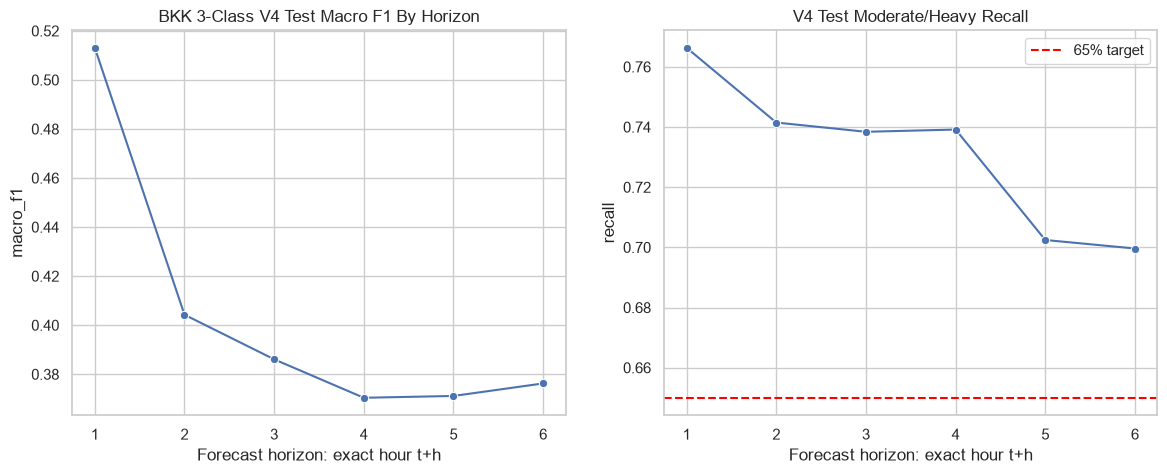

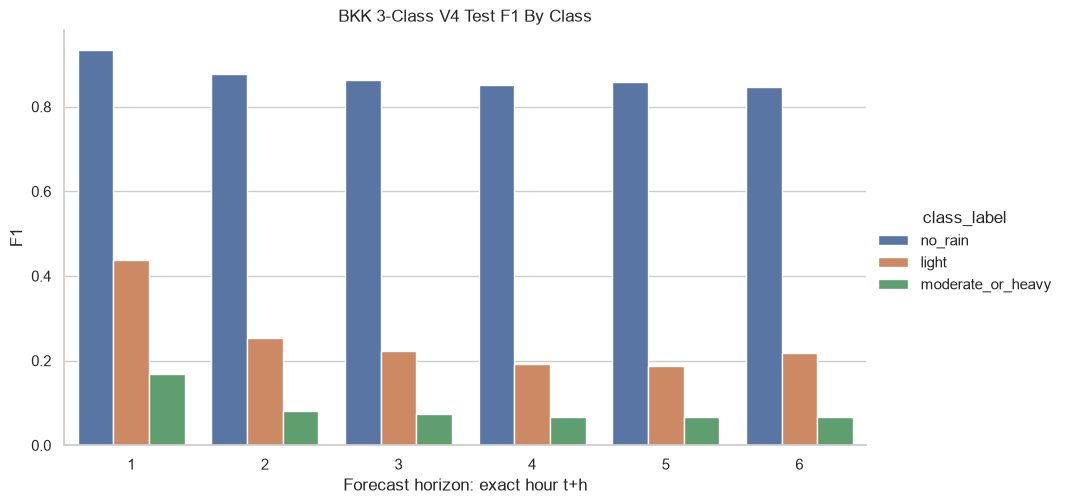

,model,model_stage,horizon_h,feature,importance,is_neighbor_feature
77,lightgbm,light_vs_no_rain,1,pressure_msl_change_6h,1622.0000,False
74,lightgbm,light_vs_no_rain,1,wind_direction_10m,1605.0000,False
76,lightgbm,light_vs_no_rain,1,pressure_msl_change_3h,1390.0000,False
116,lightgbm,light_vs_no_rain,1,neighbor_dew_point_2m_mean,1306.0000,True
95,lightgbm,light_vs_no_rain,1,hour_cos,1287.0000,False
...,...,...,...,...,...,...
706,lightgbm,strong_vs_rest,6,neighbor_pressure_msl_mean,1185.0000,True
691,lightgbm,strong_vs_rest,6,month_cos,1157.0000,False
709,lightgbm,strong_vs_rest,6,neighbor_temperature_2m_mean,1017.0000,True
708,lightgbm,strong_vs_rest,6,neighbor_pressure_msl_max,986.0000,True


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=all_metrics[all_metrics["split"] == "test"], x="horizon_h", y="macro_f1", marker="o", ax=axes[0])
axes[0].set_title("BKK 3-Class V4 Test Macro F1 By Horizon")
sns.lineplot(data=class_metrics[(class_metrics["split"] == "test") & (class_metrics["class_id"] == 2)], x="horizon_h", y="recall", marker="o", ax=axes[1])
axes[1].axhline(0.65, color="red", linestyle="--", label="65% target")
axes[1].set_title("V4 Test Moderate/Heavy Recall")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("Forecast horizon: exact hour t+h")
plt.show()

sns.catplot(
    data=class_metrics[class_metrics["split"] == "test"],
    x="horizon_h",
    y="f1",
    hue="class_label",
    kind="bar",
    height=5,
    aspect=1.8,
)
plt.title("BKK 3-Class V4 Test F1 By Class")
plt.xlabel("Forecast horizon: exact hour t+h")
plt.ylabel("F1")
plt.show()

display(feature_importance.sort_values(["model_stage", "horizon_h", "importance"], ascending=[True, True, False]).groupby(["model_stage", "horizon_h"]).head(10))


## 10. Save BKK 3-Class V4 Models And Results

In [11]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for horizon, model in strong_models.items():
    joblib.dump(model, MODEL_DIR / f"bkk_3_class_v4_exact_next_{horizon}h_strong_vs_rest_lightgbm.joblib")

for horizon, model in light_models.items():
    joblib.dump(model, MODEL_DIR / f"bkk_3_class_v4_exact_next_{horizon}h_light_vs_no_rain_lightgbm.joblib")

target_balance.to_csv(MODEL_DIR / "bkk_3_class_v4_target_balance.csv", index=False)
thresholds.to_csv(MODEL_DIR / "bkk_3_class_v4_thresholds.csv", index=False)
threshold_search_results.to_csv(MODEL_DIR / "bkk_3_class_v4_threshold_search.csv", index=False)
all_metrics.to_csv(MODEL_DIR / "bkk_3_class_v4_metrics.csv", index=False)
class_metrics.to_csv(MODEL_DIR / "bkk_3_class_v4_class_metrics.csv", index=False)
confusion_results.to_csv(MODEL_DIR / "bkk_3_class_v4_confusion_matrices.csv", index=False)
feature_importance.to_csv(MODEL_DIR / "bkk_3_class_v4_lightgbm_feature_importance.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "precompute_table": PRECOMPUTE_TABLE_NAME,
    "target_type": "rain_3class_exact_at_t_plus_h_strong_first_recall_constrained",
    "horizons": HORIZONS,
    "intensity_thresholds_mm": INTENSITY_THRESHOLDS_MM,
    "class_labels": CLASS_LABELS,
    "model": "strong_first_two_stage_lightgbm",
    "stage_1": "strong_vs_rest",
    "stage_2": "light_vs_no_rain",
    "target_validation_strong_recall": TARGET_VALIDATION_STRONG_RECALL,
    "feature_set": "neighbor_grid",
    "feature_columns": FEATURE_COLUMNS,
    "future_precip_columns": FUTURE_PRECIP_COLUMNS,
    "final_target_columns": FINAL_TARGET_COLUMNS,
    "strong_target_columns": STRONG_TARGET_COLUMNS,
    "light_target_columns": LIGHT_TARGET_COLUMNS,
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "sample_rows": SAMPLE_ROWS,
    "model_dir": str(MODEL_DIR),
    "thresholds": thresholds.to_dict(orient="records"),
    "target_balance": target_balance.to_dict(orient="records"),
    "metrics": all_metrics.to_dict(orient="records"),
    "class_metrics": class_metrics.to_dict(orient="records"),
}
(MODEL_DIR / "bkk_3_class_v4_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved BKK 3-Class V4 models and result CSVs to {MODEL_DIR}")


Saved BKK 3-Class V4 models and result CSVs to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\BKK_3_Class_V4
